In [35]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, List, Sequence,Literal,Annotated

In [7]:
class EmployeeState(TypedDict):
    name: str
    salary: float
    age: int
    decision: Literal['std_hr', 'forced_hr']
    result:str

In [8]:
def analyze_employee(state:EmployeeState)->EmployeeState:
    age = state['age']
    salary = state['salary']
    if age <= 30 and salary < 40000:
        state['decision'] = 'std_hr'
    else:
        state['decision'] = 'forced_hr'
    print(f"Le dossier de {state['name']} a été analysé")
    return state    

In [9]:
def standard_hr_process(state:EmployeeState)->EmployeeState:
    state['result'] = f"Le dossier de {state['name']} a été traité de manière standard."
    print("="*80)
    print(f"Le dossier de {state['name']} a été traité de manière standard.")
    print("="*80)  
    return state

In [10]:
def forced_hr_process(state:EmployeeState)->EmployeeState:
    state['result'] = f"Le dossier de {state['name']} a été traité de manière forcée."
    print("="*80)
    print(f"Le dossier de {state['name']} a été traité de manière forcée.")
    print("="*80)  
    return state

In [11]:
def router(state:EmployeeState)->str:
    return state['decision']

In [25]:
workflow = StateGraph(EmployeeState)

workflow.add_node('analyze_node', analyze_employee)
workflow.add_node('std_hr', standard_hr_process)
workflow.add_node('forced_hr', forced_hr_process)

workflow.add_edge(START, 'analyze_node')

workflow.add_conditional_edges(
    'analyze_node',
    router,
    {
        'std_hr': 'std_hr',
        'forced_hr': 'forced_hr'
    }
)

workflow.add_edge('std_hr', END)
workflow.add_edge('forced_hr', END)

graph = workflow.compile()

In [27]:
from IPython.display import Image

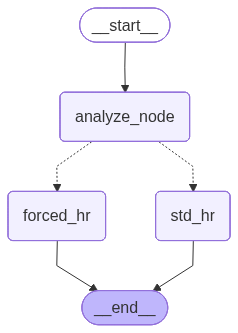

In [28]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
result= graph.invoke({
    'name': 'Alice',
    'age': 28,
    'salary': 35000
})

Le dossier de Alice a été analysé
Le dossier de Alice a été traité de manière standard.


In [31]:
result = graph.invoke({
    'name': 'Bob',
    'age': 35,
    'salary': 45000
})

Le dossier de Bob a été analysé
Le dossier de Bob a été traité de manière forcée.


In [53]:
from langchain.tools import tool
from langchain.messages import SystemMessage,AIMessage,ToolMessage,HumanMessage
from langchain_core.messages import BaseMessage , AnyMessage
from langgraph.graph import add_messages
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import InMemorySaver

In [33]:
@tool
def add(a: float, b: float):
    """
    Add two float numbers
    """
    print(f"Adding 2 numbers a={a}, b={b}\n")
    return a + b


@tool
def multiply(a: float, b: float):
    """
    Multiply two float numbers
    """
    print(f"Multiplying 2 numbers a={a}, b={b}\n")
    return a * b


@tool
def divide(a: float, b: float):
    """
    Divide two float numbers
    """
    print(f"Dividing 2 numbers a={a}, b={b}\n")
    
    if b == 0:
        return "Error: Division by zero is not allowed"
    
    return a / b



tools = [add, multiply, divide]


In [40]:
class AgentState (TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

In [41]:
import os 
from dotenv import load_dotenv

In [43]:
load_dotenv()

True

In [47]:
llm=ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools = llm.bind_tools(tools=tools)

In [48]:
def assistant(state: AgentState)->AgentState:
  response = llm_with_tools.invoke(state['messages'])
  print("*"*50)
  print("llm invoked")
  return {"messages":[response]}

In [49]:
def shoud_continue(state : AgentState):
   last_message = state['messages'][-1]
   if not last_message.tool_calls:
     return "end"
   else:
    return "continue"  

In [50]:
workflow= StateGraph(AgentState)
workflow.add_node("assistant", assistant)
workflow.add_node("tools", ToolNode(tools=tools))
workflow.set_entry_point("assistant") 
workflow.add_conditional_edges(
    "assistant",
    shoud_continue, {
        "end":END, 
        "continue":"tools"
    }
)
workflow.add_edge("tools","assistant")
memory=InMemorySaver()
graph=workflow.compile(checkpointer=memory)

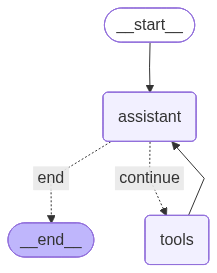

In [51]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [59]:
config={"configurable":{"thread_id":1}}
resp = graph.invoke({
    "messages":[
        HumanMessage("add 5 to 20 then multiply the result by 2 then give me a proverbe in arabic ")
    ]

},config=config)

**************************************************
llm invoked
Adding 2 numbers a=5.0, b=20.0

**************************************************
llm invoked
Multiplying 2 numbers a=25.0, b=2.0

**************************************************
llm invoked


In [60]:
print(resp['messages'][-1].content)

The result of adding 5 to 20 is 25, and multiplying that result by 2 gives 50.

Here is a proverb in Arabic: "الصبر مفتاح الفرج" which translates to "Patience is the key to relief."


In [61]:
resp = graph.invoke({
    "messages":[
        HumanMessage("Bonjour je m'appellle Armstrong ")
    ]

},config=config)
print(resp['messages'][-1].content)

**************************************************
llm invoked
Bonjour Armstrong ! Comment puis-je vous aider aujourd'hui ?


In [62]:
resp = graph.invoke({
    "messages":[
        HumanMessage("Bonjour comment je m appelle ")
    ]

},config=config)
print(resp['messages'][-1].content)

**************************************************
llm invoked
Bonjour ! Vous vous appelez Armstrong. Comment puis-je vous aider aujourd'hui ?
